In [1]:
import numpy as np
import pandas as pd
import mne
import math
import os

In [2]:
# loading windows
base_dir = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\scope\demo1023"
theta_df = []
csv_files = [f for f in os.listdir(base_dir) if f.endswith(".csv")]
csv_files.sort(key=lambda f: os.path.getctime(os.path.join(base_dir, f)))

for idx, window in enumerate(csv_files):
    path = os.path.join(base_dir, csv_files[idx])
    idx_df = pd.read_csv(path) 
    theta_df.append(idx_df)
theta_df[1]

,LSL Time,Raw,Theta Bandpass,Power,Moving Average,Z-score,Hold,Trigger Channel,offline z-score,median,mad,LIFU,t_rel,idx
0,812516.031095,50865.988281,0.434790,0.189042,0.546605,-0.424257,-0.389558,0.211975,-0.389558,-0.152660,-0.389558,0.0,-1.996378,1
1,812516.040321,53491.710938,0.403409,0.162739,0.491597,-0.437417,-0.389558,0.270273,-0.389558,-0.152660,-0.389558,0.0,-1.987152,1
2,812516.041448,53329.398438,0.352744,0.124429,0.449313,-0.447533,-0.389558,0.238812,-0.389558,-0.152660,-0.389558,0.0,-1.986025,1
3,812516.041697,50672.367188,0.283080,0.080134,0.419231,-0.454729,-0.389558,0.120169,-0.389558,-0.152660,-0.389558,0.0,-1.985776,1
4,812516.048191,50498.562500,0.195239,0.038118,0.399952,-0.459342,-0.389558,-0.003764,-0.389558,-0.152660,-0.389558,0.0,-1.979282,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1742,812523.003448,50962.593750,0.367099,0.134761,1.754263,-0.135344,-0.120196,0.193732,-0.120196,-0.096301,-0.120196,0.0,4.975975,1
1743,812523.013865,53690.648438,-0.027406,0.000751,1.723563,-0.142688,-0.120196,37.463928,-0.120196,-0.096301,-0.120196,0.0,4.986392,1
1744,812523.014095,54326.230469,-0.425882,0.181375,1.699790,-0.148376,-0.120196,21.693207,-0.120196,-0.096301,-0.120196,0.0,4.986622,1
1745,812523.014295,51811.105469,-0.818847,0.670510,1.689278,-0.150891,-0.120196,-24.354889,-0.120196,-0.096301,-0.120196,0.0,4.986822,1


In [6]:
#when it sonicates
lifu_markers = pd.read_csv("lifu_markers_1_2back_-1580742246.csv")
lifu_on_df = lifu_markers[lifu_markers["marker"] == "LIFU_ON"]
lifu_on = np.array(lifu_on_df["LSL_timestamp"])
lifu_on

array([812470.4154841, 812518.0274728])

In [7]:
#finding baseline median and mean
medians = []
mads = []
tol = 0.002

for idx, event in enumerate(lifu_on):
    df = theta_df[idx]
    diff = np.abs(df["LSL Time"].values - event)
    i = np.argmin(diff)
    row = df.iloc[i]
    median = row["median"]
    mad = row["mad"]
    medians.append(median)
    mads.append(mad)
print(f"medians = {medians}")
print(f"mads = {mads}")

medians = [-0.0255945622920989, -0.1049931645393371]
mads = [1.69853937625885, 1.596295714378357]


In [8]:
# median percent change calculation
idx = 1
pre_sonication= []
post_sonication= []
percent_change_df = pd.DataFrame(lifu_on, columns=["Time"])

#for loop
for idx, event in enumerate(lifu_on):
    df = theta_df[idx]
    pre_df = df[df["LSL Time"]<= event]
    pre_mean = np.mean(np.array(pre_df["Hold"].dropna()))
    post_df = df[df["LSL Time"]>= event]
    post_mean = np.mean(np.array(post_df["Hold"].dropna()))
    pre_sonication.append(pre_mean)
    post_sonication.append(post_mean)
percent_change_df["pre average median"] = pre_sonication
percent_change_df["post average median"] = post_sonication
# CHECK IF EQUATION IS CORRECT -- also slope
percent_change_df["percent change %"] = 100* (percent_change_df["post average median"] - percent_change_df["pre average median"])/ percent_change_df["pre average median"]
percent_change_df

,Time,pre average median,post average median,percent change %
0,812470.415484,17.343584,-0.047749,-100.275312
1,812518.027473,0.234465,0.130137,-44.496272


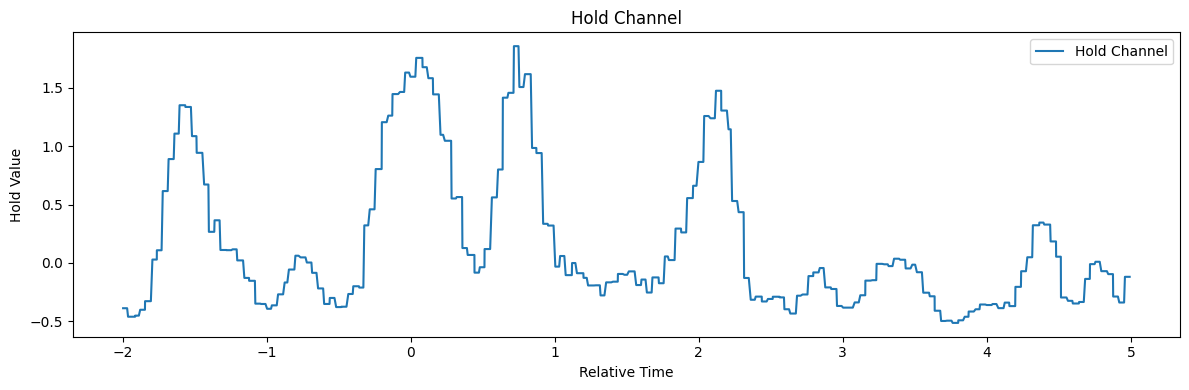

In [12]:
# plot thetas
import matplotlib.pyplot as plt

df = theta_df[1]
#df = df[df['t_rel'] > -1]


plt.figure(figsize=(12,4))
plt.plot(df["t_rel"], df["Hold"], label="Hold Channel")
plt.xlabel("Relative Time")
plt.ylabel("Hold Value")
plt.title("Hold Channel")
plt.legend()
plt.tight_layout()
plt.show()